In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("Supermarket.xlsx")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year (optional)
#df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

In [3]:
df.head()

,Order ID,Order Date,Customer Name,City,Country,Region,Segment,Ship Date,Ship Mode,State,Month
0,BN-2011-7407039,2011-01-01,Ruby Patel,Stockholm,Sweden,North,Home Office,2011-01-05,Economy Plus,Stockholm,2011-01
1,AZ-2011-9050313,2011-01-03,Summer Hayward,Southport,United Kingdom,North,Consumer,2011-01-07,Economy,England,2011-01
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,Valence,France,Central,Consumer,2011-01-08,Economy,Auvergne-Rhône-Alpes,2011-01
3,BN-2011-2819714,2011-01-04,Mary Parker,Birmingham,United Kingdom,North,Corporate,2011-01-09,Economy,England,2011-01
4,AZ-2011-617423,2011-01-05,Daniel Burke,Echirolles,France,Central,Home Office,2011-01-07,Priority,Auvergne-Rhône-Alpes,2011-01


In [4]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'City', 'Country', 'Region',
       'Segment', 'Ship Date', 'Ship Mode', 'State', 'Month'],
      dtype='str')

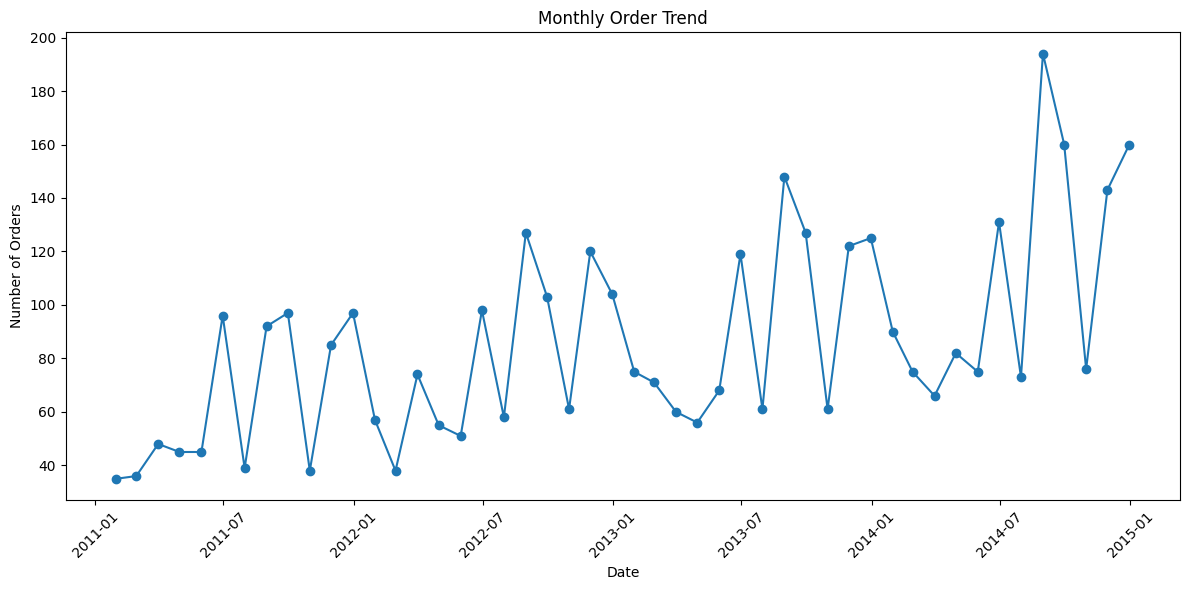

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_orders = df.resample('ME', on='Order Date')['Order ID'].count()

plt.figure(figsize=(12,6))
plt.plot(monthly_orders, marker='o')

plt.title("Monthly Order Trend")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

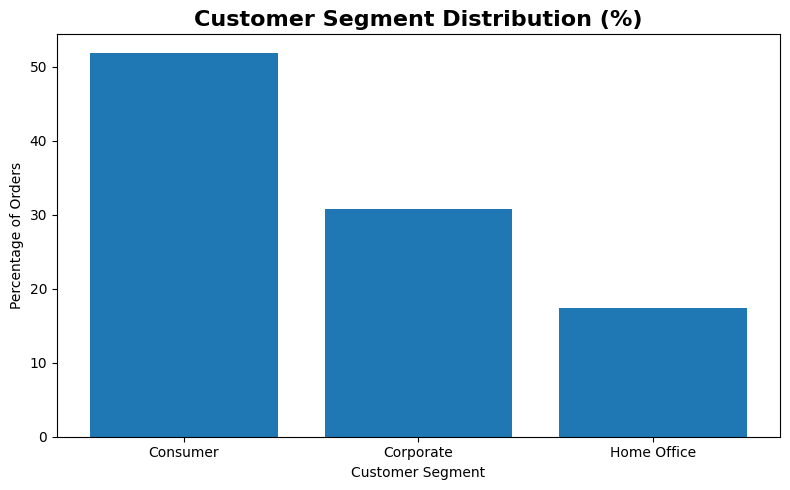

In [16]:
segment_percentage = df['Segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
plt.bar(segment_percentage.index, segment_percentage.values)

plt.title("Customer Segment Distribution (%)", fontsize=16, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Orders")

plt.tight_layout()
plt.show()

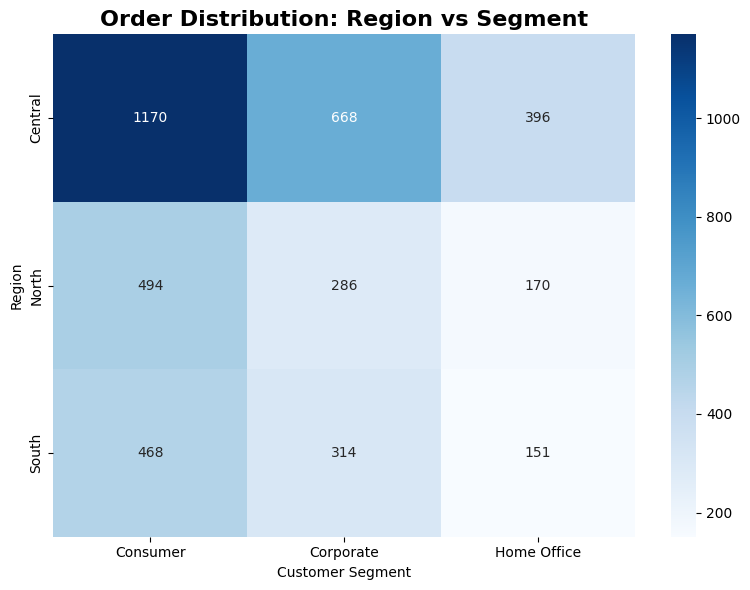

In [8]:
import seaborn as sns

# Create cross-tabulation
pivot = pd.crosstab(df['Region'], df['Segment'])

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,        # show numbers inside cells
    fmt='d',           # integer format
    cmap='Blues',      # clean color theme
    cbar=True
)

plt.title("Order Distribution: Region vs Segment",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Customer Segment")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import plotly.express as px

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

country_month = (
    df.groupby(['Month', 'Country'])['Order ID']
      .count()
      .reset_index()
)

country_month.columns = ['Month', 'Country', 'Order_Count']

In [14]:
fig = px.bar(
    country_month,
    x="Order_Count",
    y="Country",
    color="Country",
    animation_frame="Month",
    orientation='h',
    title="Bar Chart Race: Orders by Country"
)

fig.update_layout(template="plotly_white")
fig.show()
fig.write_image("dashboard.png", scale=3)